# IoT Farm Deodorization Data-to-RL Workflow

This notebook is organized into parts: data ingestion, cleaning, simulation, scenario checks, RL environment setup, training, evaluation, and optional online updates.


## 1. Convert Raw JSON to Wide CSV

Transform per-sensor JSON data retrieved from ThingsBoard into timestamp-aligned wide tables for each device.

Outputs `pi-1-data.csv` and `pi-2-data.csv`.


In [27]:
from pathlib import Path
from typing import TypeAlias
import json
import pandas as pd

SensorRecord: TypeAlias = dict[str, int | str]
SensorPayload: TypeAlias = dict[str, list[SensorRecord]]
EXPECTED_SENSOR_COLUMNS: list[str] = [
    "aqi-1",
    "aqi-2",
    "aqi-3",
    "aqi-4",
    "aqi-5",
    "co2-1",
    "co2-2",
    "co2-3",
    "co2-4",
    "co2-5",
    "humi-1",
    "humi-2",
    "humi-3",
    "humi-4",
    "humi-5",
    "temp-1",
    "temp-2",
    "temp-3",
    "temp-4",
    "temp-5",
    "tvoc-1",
    "tvoc-2",
    "tvoc-3",
    "tvoc-4",
    "tvoc-5",
]
PI2_DROP_COLUMNS: list[str] = ["aqi-5", "co2-5", "humi-5", "temp-5", "tvoc-5"]

# Workspace root containing JSON inputs.
BASE_DIR: Path = Path.cwd()
INPUT_FILES: list[Path] = [BASE_DIR / "pi-1-data.json", BASE_DIR / "pi-2-data.json"]


def json_to_wide_dataframe(json_path: Path) -> pd.DataFrame:
    """Convert one sensor JSON file into a wide DataFrame keyed by timestamp."""
    with json_path.open("r", encoding="utf-8") as f:
        payload: SensorPayload = json.load(f)

    long_frames: list[pd.DataFrame] = []

    for sensor_name, records in payload.items():
        if not isinstance(records, list):
            continue

        sensor_df = pd.DataFrame(records)
        if (
            sensor_df.empty
            or "ts" not in sensor_df.columns
            or "value" not in sensor_df.columns
        ):
            continue

        sensor_df = sensor_df[["ts", "value"]].rename(
            columns={"ts": "timestamp", "value": "value"}
        )
        sensor_df["value"] = pd.to_numeric(
            sensor_df["value"].replace("N/A", pd.NA), errors="coerce"
        )
        sensor_df["sensor"] = sensor_name
        long_frames.append(sensor_df)

    if not long_frames:
        return pd.DataFrame(columns=["timestamp", *EXPECTED_SENSOR_COLUMNS])

    long_df = pd.concat(long_frames, ignore_index=True)
    wide_df = long_df.pivot_table(
        index="timestamp", columns="sensor", values="value", aggfunc="last"
    )
    wide_df = wide_df.reset_index()
    wide_df.columns.name = None
    wide_df["timestamp"] = pd.to_numeric(wide_df["timestamp"], errors="coerce").astype(
        "Int64"
    )
    wide_df = wide_df.reindex(columns=["timestamp", *EXPECTED_SENSOR_COLUMNS])
    wide_df = wide_df.sort_values("timestamp", na_position="last").reset_index(
        drop=True
    )
    return wide_df


summaries: list[dict[str, int | str]] = []
for input_path in INPUT_FILES:
    if not input_path.exists():
        print(f"Skipping missing file: {input_path.name}")
        continue

    df = json_to_wide_dataframe(input_path)

    # Sensor-5 on pi-2 is known failed during this time window.
    if input_path.name.startswith("pi-2"):
        df = df.drop(columns=PI2_DROP_COLUMNS, errors="ignore")

    output_path = input_path.with_suffix(".csv")
    df.to_csv(output_path, index=False)

    summaries.append(
        {
            "input": input_path.name,
            "output": output_path.name,
            "rows": int(df.shape[0]),
            "columns": int(df.shape[1]),
        }
    )

summary_df = pd.DataFrame(summaries)
summary_df

,input,output,rows,columns
0,pi-1-data.json,pi-1-data.csv,4861,26
1,pi-2-data.json,pi-2-data.csv,4838,21


## 2. Clean, Aggregate, and Plot 5-Min Data

Denoise sensor spikes, resample to 5-minute buckets, and aggregate across sensor locations.

Outputs cleaned files (e.g., `pi-1-data-clean-5min.csv`) and quick QA plots for TVOC, CO2, humidity, temperature, and valid-sensor count.


In [28]:
from typing import Final

RESAMPLE_RULE: Final[str] = "5min"
SHORT_GAP_MAX: Final[int] = 2  # <=10 minutes
MEDIUM_GAP_MAX: Final[int] = 12  # <=60 minutes

# Minimum absolute jump to treat as possible glitch per sensor family.
DELTA_MIN_JUMP: Final[dict[str, float]] = {
    "co2": 180.0,
    "humi": 8.0,
    "temp": 3.0,
    "tvoc": 350.0,
}

FAMILY_SENSOR_COLUMNS: dict[str, list[str]] = {
    "tvoc": ["tvoc-1", "tvoc-2", "tvoc-3", "tvoc-4", "tvoc-5"],
    "co2": ["co2-1", "co2-2", "co2-3", "co2-4", "co2-5"],
    "humidity": ["humi-1", "humi-2", "humi-3", "humi-4", "humi-5"],
    "temp": ["temp-1", "temp-2", "temp-3", "temp-4", "temp-5"],
}


def _sensor_family(column_name: str) -> str:
    if "-" in column_name:
        return column_name.split("-", 1)[0]
    return column_name


def _mark_delta_glitches(
    df_in: pd.DataFrame, value_cols: list[str], z_threshold: float = 6.0
) -> tuple[pd.DataFrame, dict[str, int]]:
    """Mark sample as glitch when jump from previous sample is abnormally high."""
    df_out = df_in.copy()
    glitch_counts: dict[str, int] = {}

    for col in value_cols:
        family = _sensor_family(col)
        s = pd.to_numeric(df_out[col], errors="coerce")
        abs_delta = s.diff().abs()

        delta_median = abs_delta.median(skipna=True)
        delta_mad = (abs_delta - delta_median).abs().median(skipna=True)

        min_jump = DELTA_MIN_JUMP.get(family, 0.0)
        if pd.isna(delta_median):
            glitch_counts[col] = 0
            continue

        if pd.isna(delta_mad) or delta_mad == 0:
            robust_limit = float(delta_median) * 3.0
        else:
            robust_limit = float(delta_median) + z_threshold * 1.4826 * float(delta_mad)

        jump_limit = max(min_jump, robust_limit)
        glitch_mask = abs_delta > jump_limit

        glitch_counts[col] = int(glitch_mask.sum())
        df_out.loc[glitch_mask, col] = pd.NA

    return df_out, glitch_counts


def _apply_selective_gap_fill(
    series_in: pd.Series,
) -> tuple[pd.Series, pd.Series]:
    """Short gaps: ffill, medium gaps: linear interpolate, long gaps: keep missing for drop."""
    s = series_in.copy()
    missing_mask = s.isna()
    group_id = missing_mask.ne(missing_mask.shift(fill_value=False)).cumsum()
    missing_run_length = missing_mask.groupby(group_id).transform("sum")

    short_gap_mask = missing_mask & (missing_run_length <= SHORT_GAP_MAX)
    medium_gap_mask = (
        missing_mask
        & (missing_run_length > SHORT_GAP_MAX)
        & (missing_run_length <= MEDIUM_GAP_MAX)
    )
    long_gap_mask = missing_mask & (missing_run_length > MEDIUM_GAP_MAX)

    s_ffill = s.ffill(limit=SHORT_GAP_MAX)
    s_interp = s.interpolate(
        method="linear", limit=MEDIUM_GAP_MAX, limit_direction="both"
    )

    s_out = s.copy()
    s_out.loc[short_gap_mask] = s_ffill.loc[short_gap_mask]
    s_out.loc[medium_gap_mask] = s_interp.loc[medium_gap_mask]
    return s_out, long_gap_mask


def clean_align_5min(df_raw: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, int]]:
    df = df_raw.copy()

    # Parse and index time.
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce").astype("Int64")
    df = df.dropna(subset=["timestamp"]).copy()
    df["time"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    df = df.drop(columns=["timestamp"]).set_index("time").sort_index()

    # Keep last if duplicate timestamps present.
    before_dupes = len(df)
    df = df[~df.index.duplicated(keep="last")]
    removed_dupes = before_dupes - len(df)

    sensor_cols = [
        c for cols in FAMILY_SENSOR_COLUMNS.values() for c in cols if c in df.columns
    ]

    # Glitch cleanup from abnormal sample-to-sample jumps.
    df, delta_counts = _mark_delta_glitches(df, sensor_cols)

    # Resample to 5-minute buckets at sensor-channel level first (robust median).
    sensor_5m = df[sensor_cols].resample(RESAMPLE_RULE).median(numeric_only=True)

    # Robust aggregation per variable using median across available sensor locations.
    final_df = pd.DataFrame(index=sensor_5m.index)
    for out_col, source_cols in FAMILY_SENSOR_COLUMNS.items():
        active_cols = [c for c in source_cols if c in sensor_5m.columns]
        if active_cols:
            final_df[out_col] = sensor_5m[active_cols].median(axis=1, skipna=True)
        else:
            final_df[out_col] = pd.NA

    # Count working locations from whatever sensors actually exist in this dataset.
    available_locations = sorted(
        {
            int(c.split("-", 1)[1])
            for c in sensor_cols
            if "-" in c and c.split("-", 1)[1].isdigit()
        }
    )

    working_location_flags: list[pd.Series] = []
    for loc in available_locations:
        loc_cols = [f"tvoc-{loc}", f"co2-{loc}", f"humi-{loc}", f"temp-{loc}"]
        active_loc_cols = [c for c in loc_cols if c in sensor_5m.columns]
        if active_loc_cols:
            working_location_flags.append(
                sensor_5m[active_loc_cols].notna().any(axis=1)
            )

    if working_location_flags:
        valid_sensor_count = (
            pd.concat(working_location_flags, axis=1).sum(axis=1).astype(int)
        )
    else:
        valid_sensor_count = pd.Series(0, index=final_df.index, dtype=int)
    final_df["valid_sensor_count"] = valid_sensor_count

    # Selective missing-data handling by variable.
    long_gap_any = pd.Series(False, index=final_df.index)
    for col in ["tvoc", "co2", "humidity", "temp"]:
        final_df[col], long_gap_mask = _apply_selective_gap_fill(
            pd.to_numeric(final_df[col], errors="coerce")
        )
        long_gap_any = long_gap_any | long_gap_mask

    rows_before_long_drop = len(final_df)
    final_df = final_df.loc[~long_gap_any].copy()
    rows_dropped_long_gaps = rows_before_long_drop - len(final_df)

    final_df = final_df.reset_index()

    report = {
        "rows_in": int(len(df_raw)),
        "rows_5min": int(len(final_df)),
        "rows_with_le_2_sensors_working": int(
            (final_df["valid_sensor_count"] <= 2).sum()
        ),
        "dupe_timestamps_removed": int(removed_dupes),
        "delta_glitches_marked_total": int(sum(delta_counts.values())),
        "rows_dropped_long_gaps": int(rows_dropped_long_gaps),
        "missing_after_fill_total": int(
            final_df[["tvoc", "co2", "humidity", "temp"]].isna().sum().sum()
        ),
    }
    return final_df, report


cleaned_reports: list[dict[str, int | str]] = []
cleaned_frames: dict[str, pd.DataFrame] = {}

for input_name in ["pi-1-data.csv", "pi-2-data.csv"]:
    input_path = BASE_DIR / input_name
    if not input_path.exists():
        print(f"Skipping missing CSV: {input_name}")
        continue

    raw_df = pd.read_csv(input_path)
    cleaned_df, stats = clean_align_5min(raw_df)
    cleaned_frames[input_name] = cleaned_df

    out_name = input_name.replace(".csv", "-clean-5min.csv")
    out_path = BASE_DIR / out_name
    cleaned_df.to_csv(out_path, index=False)

    cleaned_reports.append(
        {
            "input": input_name,
            "output": out_name,
            **stats,
        }
    )

clean_report_df = pd.DataFrame(cleaned_reports)
clean_report_df

,input,output,rows_in,rows_5min,rows_with_le_2_sensors_working,dupe_timestamps_removed,delta_glitches_marked_total,rows_dropped_long_gaps,missing_after_fill_total
0,pi-1-data.csv,pi-1-data-clean-5min.csv,4861,4873,24,0,236,0,0
1,pi-2-data.csv,pi-2-data-clean-5min.csv,4838,4874,48,0,110,0,0


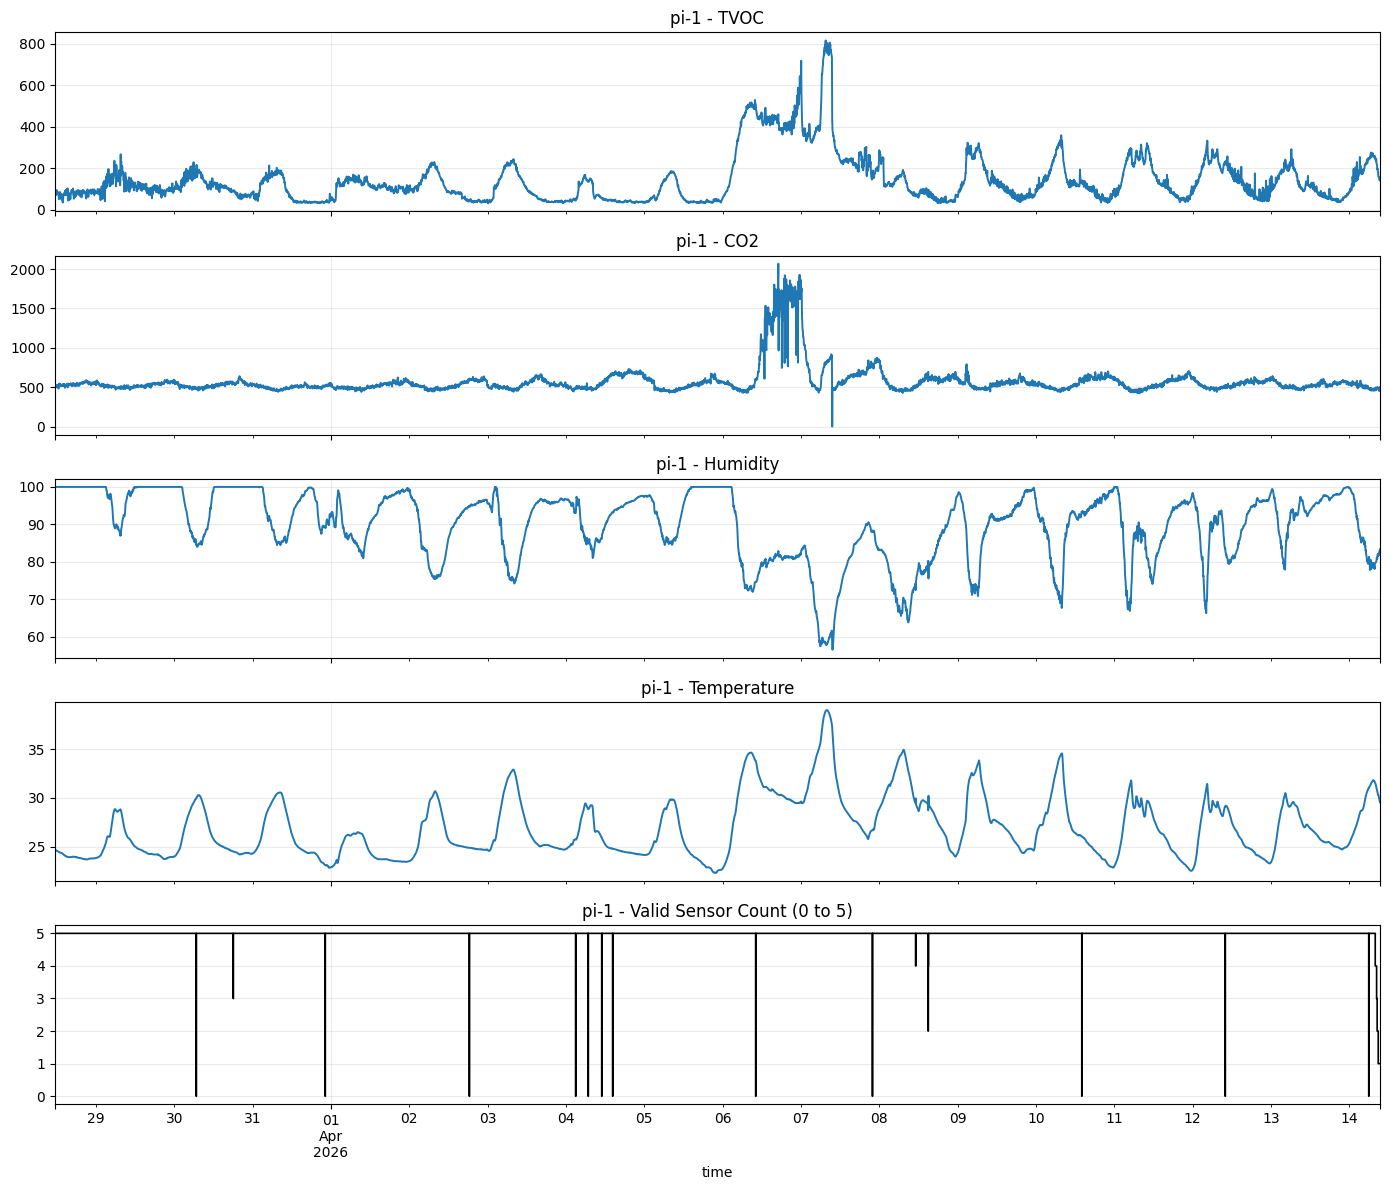

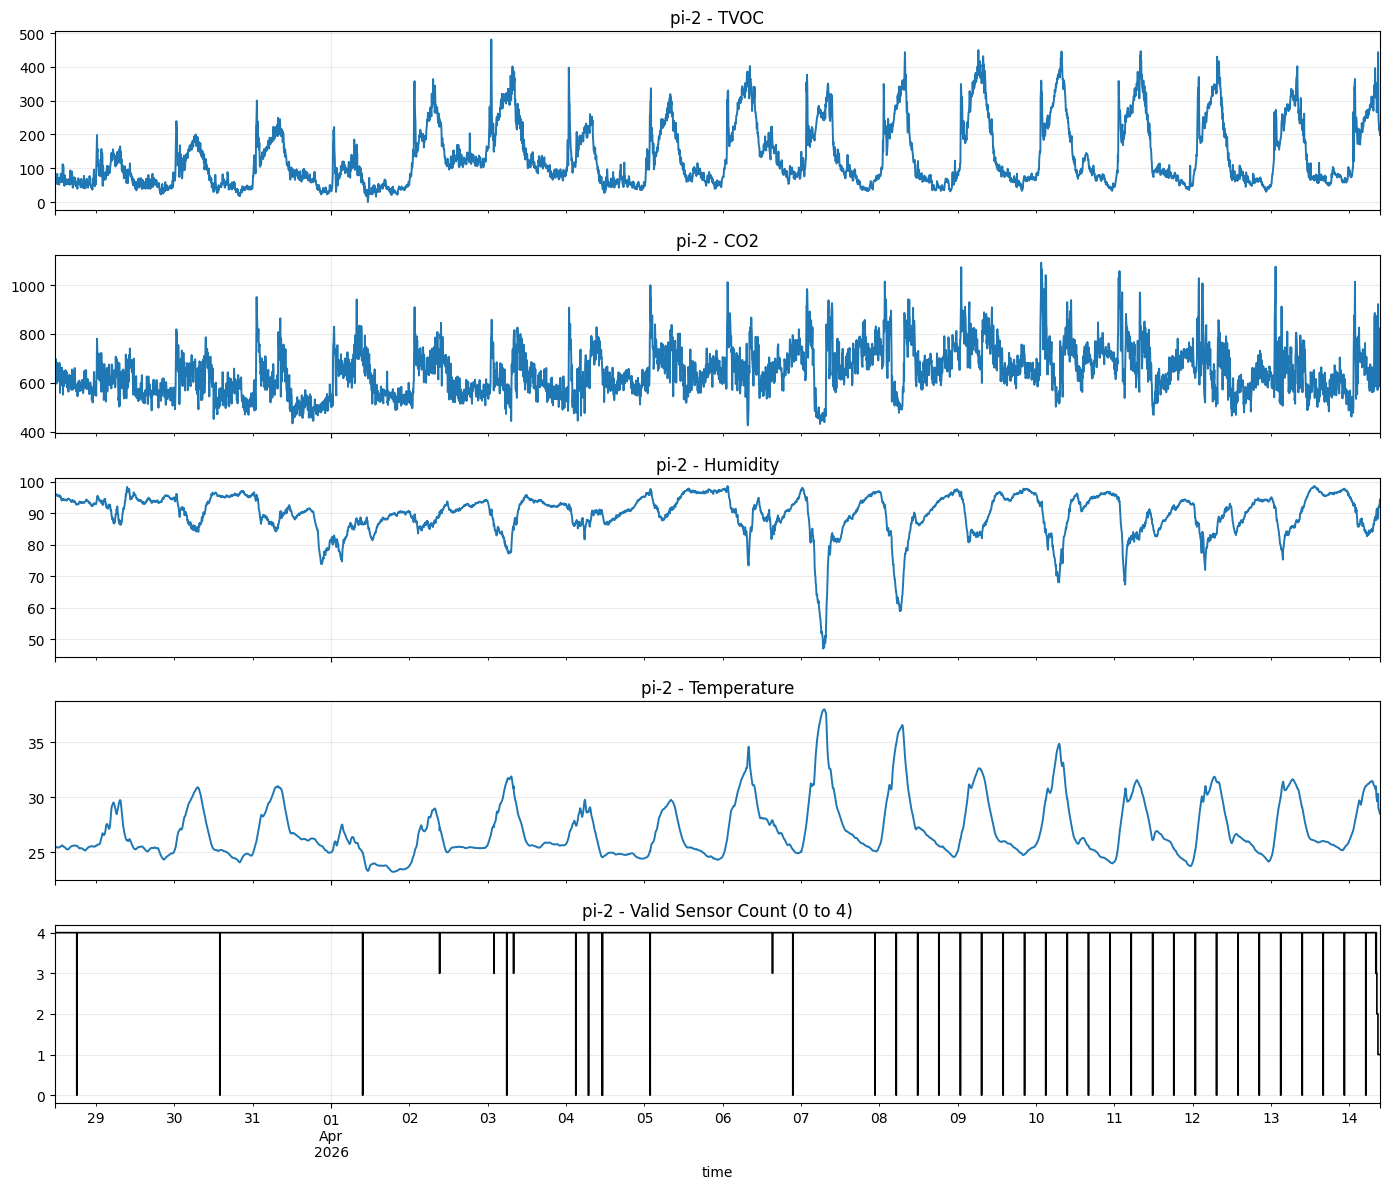

,input,output,rows_in,rows_5min,rows_with_le_2_sensors_working,dupe_timestamps_removed,delta_glitches_marked_total,rows_dropped_long_gaps,missing_after_fill_total
0,pi-1-data.csv,pi-1-data-clean-5min.csv,4861,4873,24,0,236,0,0
1,pi-2-data.csv,pi-2-data-clean-5min.csv,4838,4874,48,0,110,0,0


In [29]:
import matplotlib.pyplot as plt


def plot_cleaned_dataset(df: pd.DataFrame, title_prefix: str) -> None:
    plot_df = df.copy()
    plot_df["time"] = pd.to_datetime(plot_df["time"], utc=True)
    plot_df = plot_df.set_index("time")

    _, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

    for ax, col, label in [
        (axes[0], "tvoc", "TVOC"),
        (axes[1], "co2", "CO2"),
        (axes[2], "humidity", "Humidity"),
        (axes[3], "temp", "Temperature"),
    ]:
        if col in plot_df.columns:
            plot_df[col].plot(ax=ax, linewidth=1.4)
        ax.set_title(f"{title_prefix} - {label}")
        ax.grid(alpha=0.25)

    max_valid = (
        int(plot_df["valid_sensor_count"].max())
        if "valid_sensor_count" in plot_df.columns
        else 0
    )
    if "valid_sensor_count" in plot_df.columns:
        plot_df["valid_sensor_count"].plot(
            ax=axes[4], linewidth=1.2, color="black", drawstyle="steps-mid"
        )
    axes[4].set_title(f"{title_prefix} - Valid Sensor Count (0 to {max_valid})")
    axes[4].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


for input_name, cleaned_df in cleaned_frames.items():
    prefix = input_name.replace("-data.csv", "").replace(".csv", "")
    plot_cleaned_dataset(cleaned_df, title_prefix=prefix)

clean_report_df

In [30]:
# Calculate rolling standard deviation on numeric columns only.
for input_name, cleaned_df in cleaned_frames.items():
    print(f"Rolling std for {input_name}:")
    window = 6  # 30 minutes at 5-minute intervals
    numeric_cleaned_df = cleaned_df.select_dtypes(include=["number"])
    summary = pd.DataFrame(
        {
            "avg_rolling_std": numeric_cleaned_df.rolling(window=window).std().mean(),
            "mad": numeric_cleaned_df.diff().abs().mean(),
        }
    )
    print(summary)

Rolling std for pi-1-data.csv:
                    avg_rolling_std        mad
tvoc                      10.016281   9.681240
co2                       20.396783  21.835591
humidity                   0.456063   0.310105
temp                       0.109694   0.059754
valid_sensor_count         0.035126   0.027915
Rolling std for pi-2-data.csv:
                    avg_rolling_std        mad
tvoc                      13.343389  11.885389
co2                       40.004136  39.904576
humidity                   0.508806   0.361021
temp                       0.110225   0.059935
valid_sensor_count         0.072013   0.056844


In [31]:
import numpy as np
import pandas as pd


def one_step_abs_diff(x: pd.Series) -> pd.Series:
    x = pd.to_numeric(x, errors="coerce").dropna()
    return x.diff().abs().dropna()


def positive_excess(x: pd.Series, target: float) -> pd.Series:
    x = pd.to_numeric(x, errors="coerce").dropna()
    return (x - target).clip(lower=0.0)


# Build one combined calibration frame if you have multiple cleaned datasets.
all_frames = []
for name, df in cleaned_frames.items():
    tmp = df.copy()
    tmp["source"] = name
    all_frames.append(tmp)
cal_df = pd.concat(all_frames, ignore_index=True)

# Progress scales: typical one-step changes.
tvoc_progress_norm = one_step_abs_diff(cal_df["tvoc"]).median()
co2_progress_norm = one_step_abs_diff(cal_df["co2"]).median()

# Excess scales: typical positive violations above target.
tvoc_excess_norm = positive_excess(cal_df["tvoc"], 50.0).quantile(0.75)
co2_excess_norm = positive_excess(cal_df["co2"], 400.0).quantile(0.75)
rh_excess_norm = positive_excess(cal_df["humidity"], 90.0).quantile(0.75)

# Cold excess needs temperature-first logic.
cold_excess_norm = positive_excess(18.0 - cal_df["temp"], 0.0).quantile(0.75)

# THI excess norm from the derived THI series.
thi = (
    (0.8 * cal_df["temp"])
    + ((cal_df["humidity"] / 100.0) * (cal_df["temp"] - 14.4))
    + 46.4
)
thi_excess_norm = positive_excess(thi, 73.0).quantile(0.75)

fallbacks = {
    "TVOC_PROGRESS_NORM": tvoc_progress_norm,
    "TVOC_EXCESS_NORM": tvoc_excess_norm,
    "CO2_PROGRESS_NORM": co2_progress_norm,
    "CO2_EXCESS_NORM": co2_excess_norm,
    "THI_EXCESS_NORM": thi_excess_norm,
    "RH_EXCESS_NORM": rh_excess_norm,
    "COLD_EXCESS_NORM": cold_excess_norm,
}

for k, v in fallbacks.items():
    print(f"{k:>18s} = {v:.4f}")

TVOC_PROGRESS_NORM = 6.5000
  TVOC_EXCESS_NORM = 136.0000
 CO2_PROGRESS_NORM = 19.0000
   CO2_EXCESS_NORM = 260.5000
   THI_EXCESS_NORM = 8.9526
    RH_EXCESS_NORM = 5.7350
  COLD_EXCESS_NORM = 0.0000


In [32]:
# Observation normalization constants derived from cleaned sensor data.
# Uses p1/p99 to cover realistic range without sensitivity to spikes.

_obs_tvoc = pd.to_numeric(cal_df["tvoc"], errors="coerce").dropna()
_obs_co2 = pd.to_numeric(cal_df["co2"], errors="coerce").dropna()
_obs_temp = pd.to_numeric(cal_df["temp"], errors="coerce").dropna()
_obs_rh = pd.to_numeric(cal_df["humidity"], errors="coerce").dropna()

TVOC_OBS_DIVISOR = float(_obs_tvoc.quantile(0.99))
CO2_OBS_DIVISOR = float(_obs_co2.quantile(0.99))
TEMP_OBS_DIVISOR = float(_obs_temp.quantile(0.99))
RH_OBS_MIN = float(_obs_rh.quantile(0.01))
RH_OBS_SPAN = float(_obs_rh.quantile(0.99)) - RH_OBS_MIN

for name, val in [
    ("TVOC_OBS_DIVISOR", TVOC_OBS_DIVISOR),
    ("CO2_OBS_DIVISOR", CO2_OBS_DIVISOR),
    ("TEMP_OBS_DIVISOR", TEMP_OBS_DIVISOR),
    ("RH_OBS_MIN", RH_OBS_MIN),
    ("RH_OBS_SPAN", RH_OBS_SPAN),
]:
    print(f"{name:>18s} = {val:.4f}")

  TVOC_OBS_DIVISOR = 484.5400
   CO2_OBS_DIVISOR = 1411.4800
  TEMP_OBS_DIVISOR = 35.8051
        RH_OBS_MIN = 61.6646
       RH_OBS_SPAN = 38.3354


## 3. Build Mechanistic Simulator and Scenario Checks

Define spray-action dynamics and validate behavior with fixed/random test cases.


In [33]:
from dataclasses import dataclass, field

import numpy as np
import pandas as pd


ACTION_CONCENTRATIONS: tuple[int, ...] = (0, 500, 1000, 1500)


@dataclass(frozen=True)
class RewardWeights:
    tvoc_excess_scale: float = 1.2
    tvoc_progress_scale: float = 1.0
    use_tvoc_delta: bool = True
    tvoc_target: float = 50.0

    co2_excess_scale: float = 0.6
    co2_progress_scale: float = 0.4
    use_co2_delta: bool = True
    co2_target: float = 400.0

    thi_scale: float = 0.45
    rh_excess_scale: float = 0.15
    rh_target: float = 90.0
    cold_scale: float = 0.30

    action_scale: float = 0.9
    action_curve_power: float = 1.5
    action_urgency_scale: float = 1.5


# Normalization constants for reward components to keep them all in a reasonable range
# These were empirically chosen
TVOC_EXCESS_NORM = 17.5
CO2_EXCESS_NORM = 144.0
THI_EXCESS_NORM = 0.045
RH_EXCESS_NORM = 5.75
COLD_EXCESS_NORM = 0.040
TVOC_PROGRESS_NORM = 4.75
CO2_PROGRESS_NORM = 16.2


@dataclass
class Pi1SimulatorConfig:
    gamma: float = 0.99

    baseline_decay_frac_per_step: float = 0.40
    co2_baseline_decay_frac_per_step: float = 0.40
    time_step_minutes: float = 5.0

    # Fixed sprayed volume: 1000 mL = 1.0 L
    spray_volume_ml: float = 1000.0

    # Effect strengths
    alpha_tvoc: float = 0.0005
    alpha_rh: float = 0.0005
    alpha_temp: float = 0.0005
    alpha_co2: float = 0.00002

    # Noise scales
    tvoc_noise_sigma: float = 2.35
    rh_noise_sigma: float = 0.10
    co2_noise_sigma: float = 4.92
    temp_noise_sigma: float = 0.023

    reward: RewardWeights = field(default_factory=RewardWeights)


def wetbulb_stull(temp_c: float, rh: float) -> float:
    """https://industrialmonitordirect.com/blogs/knowledgebase/wet-bulb-temperature-calculation-for-industrial-hvac-systems"""
    return (
        temp_c * np.arctan(0.151977 * np.sqrt(rh + 8.313659))
        + np.arctan(temp_c + rh)
        - np.arctan(rh - 1.676331)
        + 0.00391838 * rh**1.5 * np.arctan(0.023101 * rh)
        - 4.686035
    )


class Pi1SpraySimulator:
    """Mechanistic simulator for RL prototyping on pi-1 5-minute data."""

    def __init__(
        self,
        pi1_df: pd.DataFrame,
        config: Pi1SimulatorConfig | None = None,
        seed: int = 7,
    ) -> None:
        self.cfg = config or Pi1SimulatorConfig()
        self.rng = np.random.default_rng(seed)

        required_cols = ["tvoc", "co2", "temp", "humidity"]
        base = pi1_df.copy()
        for col in required_cols:
            base[col] = pd.to_numeric(base[col], errors="coerce")
        base = base.dropna(subset=required_cols).reset_index(drop=True)

        self.real_tvoc = base["tvoc"].to_numpy(dtype=float)
        self.real_co2 = base["co2"].to_numpy(dtype=float)
        self.real_temp = base["temp"].to_numpy(dtype=float)
        self.real_rh = base["humidity"].to_numpy(dtype=float)
        self.T = len(base)

        # Inverse Box Model: Recover latent emissions from real data
        self.emission = np.empty(self.T, dtype=float)
        self.emission[:-1] = (
            self.real_tvoc[1:]
            - self.real_tvoc[:-1]
            + self.cfg.baseline_decay_frac_per_step * self.real_tvoc[:-1]
        )
        self.emission[-1] = self.emission[-2]

        self.co2_emission = np.empty(self.T, dtype=float)
        self.co2_emission[:-1] = (
            self.real_co2[1:]
            - self.real_co2[:-1]
            + self.cfg.co2_baseline_decay_frac_per_step * self.real_co2[:-1]
        )
        self.co2_emission[-1] = self.co2_emission[-2]

    @staticmethod
    def action_space() -> list[int]:
        return list(ACTION_CONCENTRATIONS)

    def reset(self, t0: int = 0) -> np.ndarray:
        t0 = int(np.clip(t0, 0, self.T - 1))
        return np.array(
            [
                self.real_tvoc[t0],
                self.real_co2[t0],
                self.real_temp[t0],
                self.real_rh[t0],
            ],
            dtype=float,
        )

    def step(self, state: np.ndarray, action: int, t: int) -> np.ndarray:
        t = int(np.clip(t, 0, self.T - 2))
        tvoc_current = float(state[0])
        co2_current = float(state[1])

        # Action is mg/L, sprayed volume is fixed at 1000 mL = 1 L.
        # So dose_mg is the amount of active ingredient in the sprayed liquid.
        spray_volume_L = self.cfg.spray_volume_ml / 1000.0
        dose_mg = float(action) * spray_volume_L

        # Baseline TVOC decay rate from the observed series.
        k_base = (
            -np.log(1.0 - self.cfg.baseline_decay_frac_per_step)
            / self.cfg.time_step_minutes
        )

        # Spray effect: bounded reduction proportional to current TVOC.
        tvoc_spray_loss = self.cfg.alpha_tvoc * dose_mg * tvoc_current

        tvoc_next = (
            tvoc_current * np.exp(-k_base * self.cfg.time_step_minutes)
            + self.emission[t]
            - tvoc_spray_loss
        )
        tvoc_next = max(
            0.0, tvoc_next + self.rng.normal(0.0, self.cfg.tvoc_noise_sigma)
        )

        # Spray doesn't "neutralize" CO2, but we can maybe treat is as effective removal-rate change
        k_co2_base = (
            -np.log(1.0 - self.cfg.co2_baseline_decay_frac_per_step)
            / self.cfg.time_step_minutes
        )
        k_co2_spray = self.cfg.alpha_co2 * dose_mg
        k_co2_total = k_co2_base + k_co2_spray

        co2_next = (
            co2_current * np.exp(-k_co2_total * self.cfg.time_step_minutes)
            + self.co2_emission[t]
        )

        # 300 ppm is a reasonable "impossible" lower bound for atmospheric CO2
        co2_next = max(300.0, co2_next + self.rng.normal(0.0, self.cfg.co2_noise_sigma))

        # Use the real baseline as the reference, then apply a simple bounded response.
        rh_base = self.real_rh[t + 1]
        temp_base = self.real_temp[t + 1]

        rh_next = rh_base + self.cfg.alpha_rh * dose_mg * (100.0 - rh_base)
        rh_next = rh_next + self.rng.normal(0.0, self.cfg.rh_noise_sigma)
        rh_next = float(np.clip(rh_next, 0.0, 100.0))

        wetbulb = wetbulb_stull(temp_base, rh_base)
        temp_drop = self.cfg.alpha_temp * dose_mg * (temp_base - wetbulb)
        temp_next = max(
            wetbulb,
            temp_base - temp_drop + self.rng.normal(0.0, self.cfg.temp_noise_sigma),
        )

        return np.array([tvoc_next, co2_next, temp_next, rh_next], dtype=float)

    def rollout(self, actions: list[int], t0: int = 0) -> pd.DataFrame:
        """Run one trajectory and return a DataFrame for quick inspection."""
        t = int(np.clip(t0, 0, self.T - 2))
        state = self.reset(t)

        rows: list[dict[str, float | int]] = [
            {
                "t": t,
                "action": -1,
                "tvoc": state[0],
                "co2": state[1],
                "temp": state[2],
                "rh": state[3],
            }
        ]

        for a in actions:
            next_state = self.step(state, int(a), t)
            t += 1
            rows.append(
                {
                    "t": t,
                    "action": int(a),
                    "tvoc": next_state[0],
                    "co2": next_state[1],
                    "temp": next_state[2],
                    "rh": next_state[3],
                }
            )
            state = next_state

            if t >= self.T - 2:
                break

        return pd.DataFrame(rows)

    def compute_reward(
        self,
        tvoc_prev: float,
        tvoc_next: float,
        co2_prev: float,
        co2_next: float,
        temp_prev: float,
        temp_next: float,
        rh_prev: float,
        rh_next: float,
        action: int,
        reward_weights: RewardWeights | None = None,
        is_terminal: bool = False,
    ) -> float:
        w = reward_weights or self.cfg.reward

        # Task reward: your actual objective terms.
        tvoc_excess = max(0.0, tvoc_next - w.tvoc_target) / TVOC_EXCESS_NORM
        tvoc_excess_term = -w.tvoc_excess_scale * tvoc_excess

        co2_excess = max(0.0, co2_next - w.co2_target) / CO2_EXCESS_NORM
        co2_excess_term = -w.co2_excess_scale * co2_excess

        thi_prev = (0.8 * temp_prev) + ((rh_prev / 100.0) * (temp_prev - 14.4)) + 46.4
        thi_next = (0.8 * temp_next) + ((rh_next / 100.0) * (temp_next - 14.4)) + 46.4

        thi_term = (
            -w.thi_scale * max(0.0, thi_next - max(73.0, thi_prev)) / THI_EXCESS_NORM
        )
        rh_term = -w.rh_excess_scale * max(0.0, rh_next - w.rh_target) / RH_EXCESS_NORM
        cold_term = -w.cold_scale * max(0.0, 18.0 - temp_next) / COLD_EXCESS_NORM

        tvoc_urgency = np.clip(
            (tvoc_prev - w.tvoc_target) / max(1.0, w.tvoc_target),
            0.0,
            1.0,
        )
        dose_norm = float(action) / 1500.0
        urgency_multiplier = 1.0 + w.action_urgency_scale * (1.0 - tvoc_urgency)
        action_term = (
            -w.action_scale * (dose_norm**w.action_curve_power) * urgency_multiplier
        )

        base_reward = (
            tvoc_excess_term
            + co2_excess_term
            + thi_term
            + rh_term
            + cold_term
            + action_term
        )

        # PBRS shaping term.
        phi_prev = self._phi(tvoc_prev, co2_prev, temp_prev, rh_prev, w)
        phi_next = self._phi(tvoc_next, co2_next, temp_next, rh_next, w)
        shaping = 0.0 if is_terminal else (self.cfg.gamma * phi_next - phi_prev)

        return float(base_reward + shaping)

    def _phi(
        self,
        tvoc: float,
        co2: float,
        temp: float,
        rh: float,
        w: RewardWeights,
    ) -> float:
        thi = (0.8 * temp) + ((rh / 100.0) * (temp - 14.4)) + 46.4

        tvoc_excess = max(0.0, tvoc - w.tvoc_target) / TVOC_EXCESS_NORM
        co2_excess = max(0.0, co2 - w.co2_target) / CO2_EXCESS_NORM
        thi_excess = max(0.0, thi - 73.0) / THI_EXCESS_NORM
        rh_excess = max(0.0, rh - w.rh_target) / RH_EXCESS_NORM
        cold_excess = max(0.0, 18.0 - temp) / COLD_EXCESS_NORM

        # Potential is higher for better states, so return a negative penalty sum.
        return -(
            w.tvoc_excess_scale * tvoc_excess
            + w.co2_excess_scale * co2_excess
            + w.thi_scale * thi_excess
            + w.rh_excess_scale * rh_excess
            + w.cold_scale * cold_excess
        )

### Generates compact scenario plots (including TVOC, CO2, temperature, RH, and action schedules).


Simulator initialized: T=4873 steps, action_space=[0, 500, 1000, 1500]


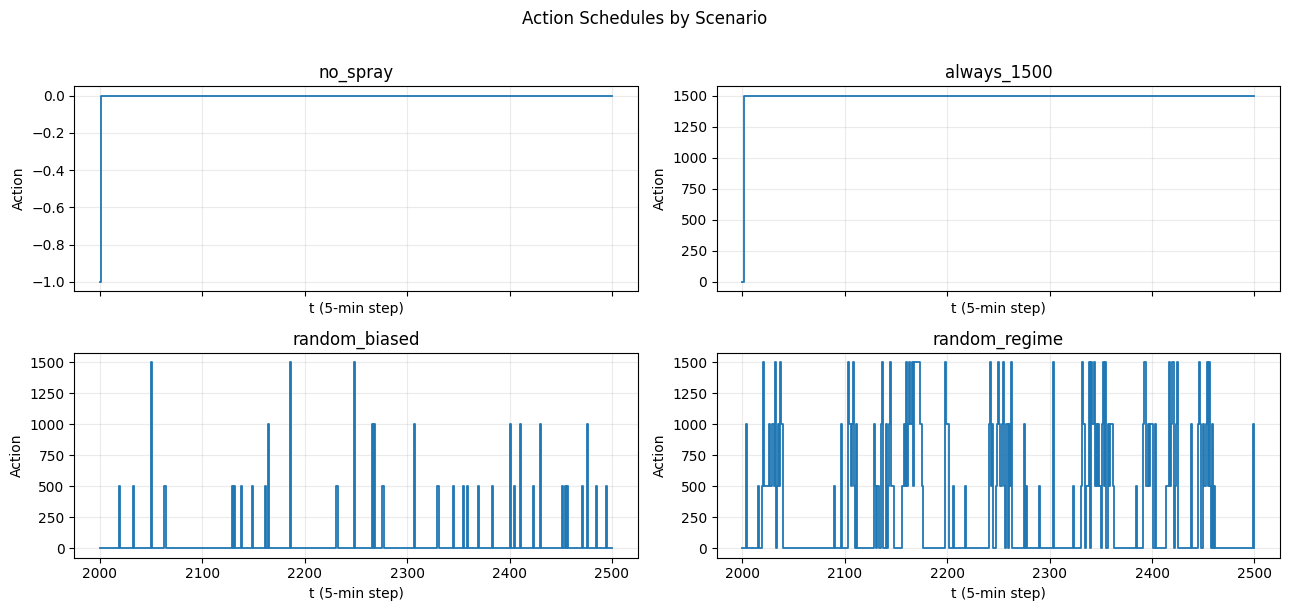

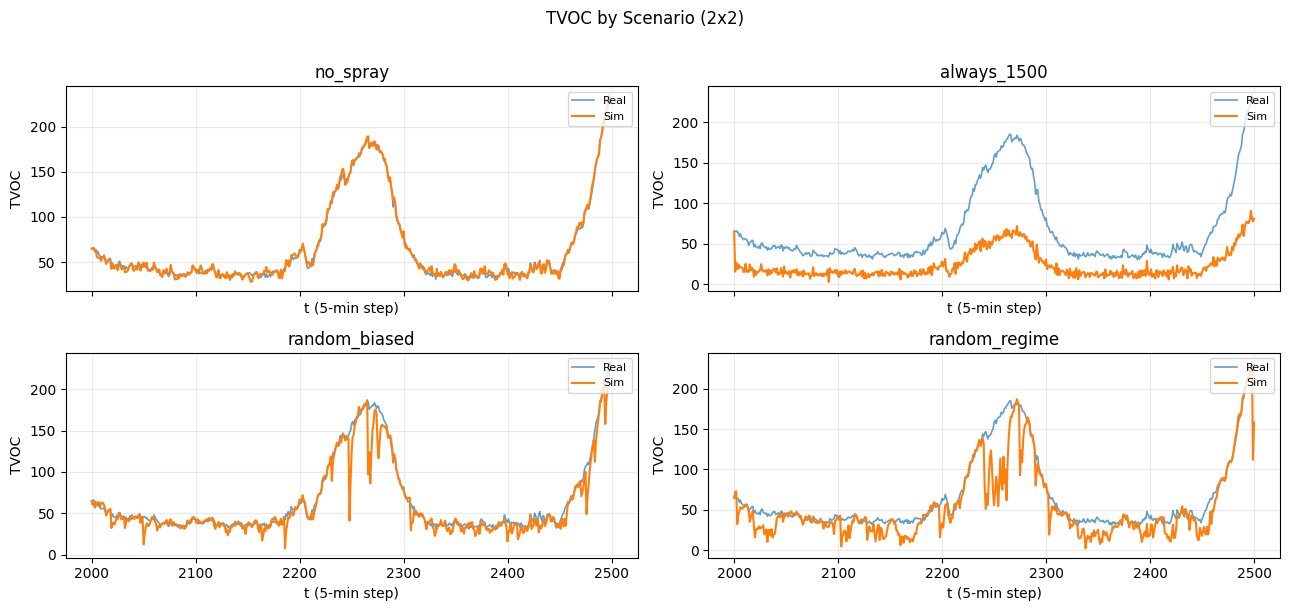

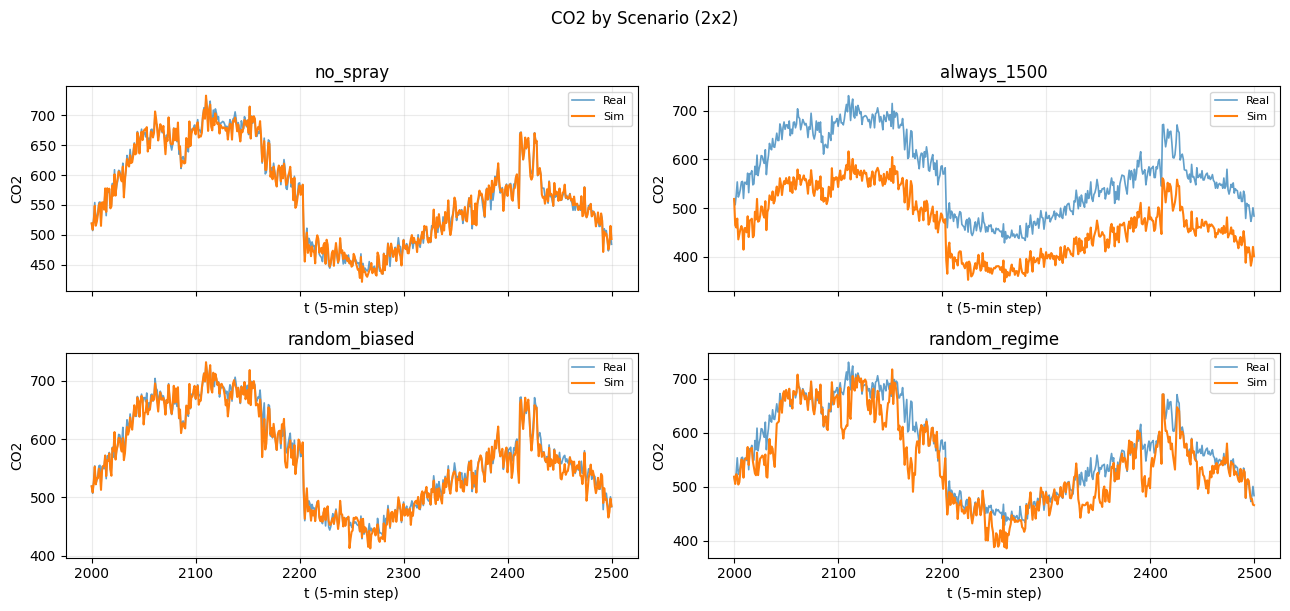

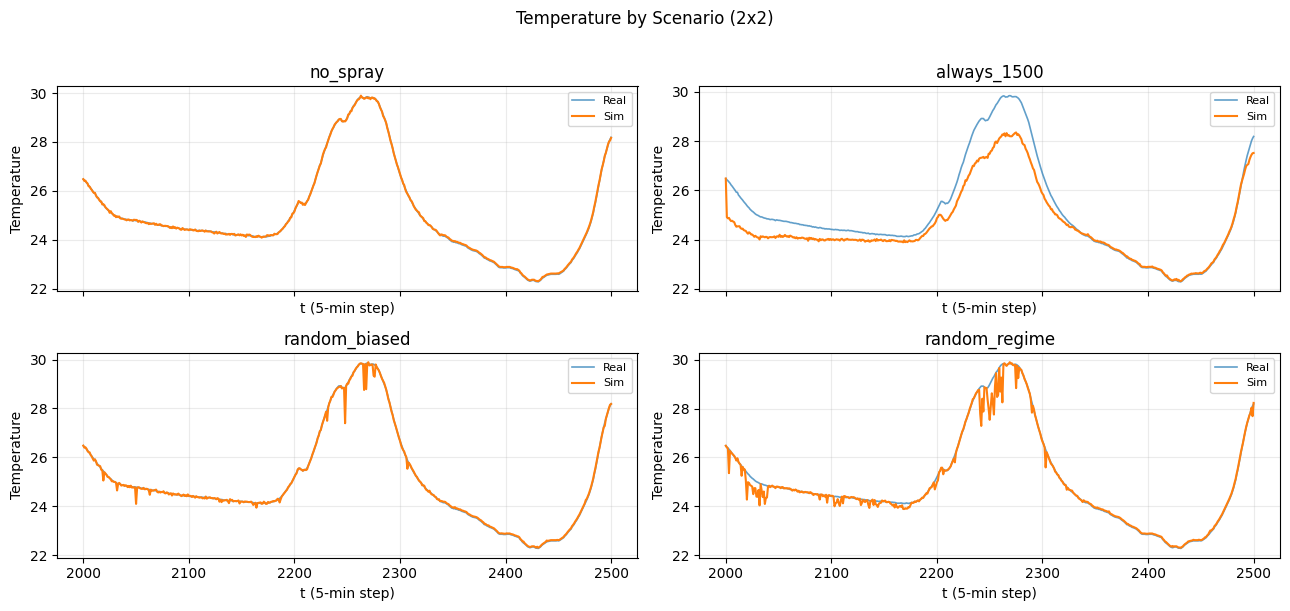

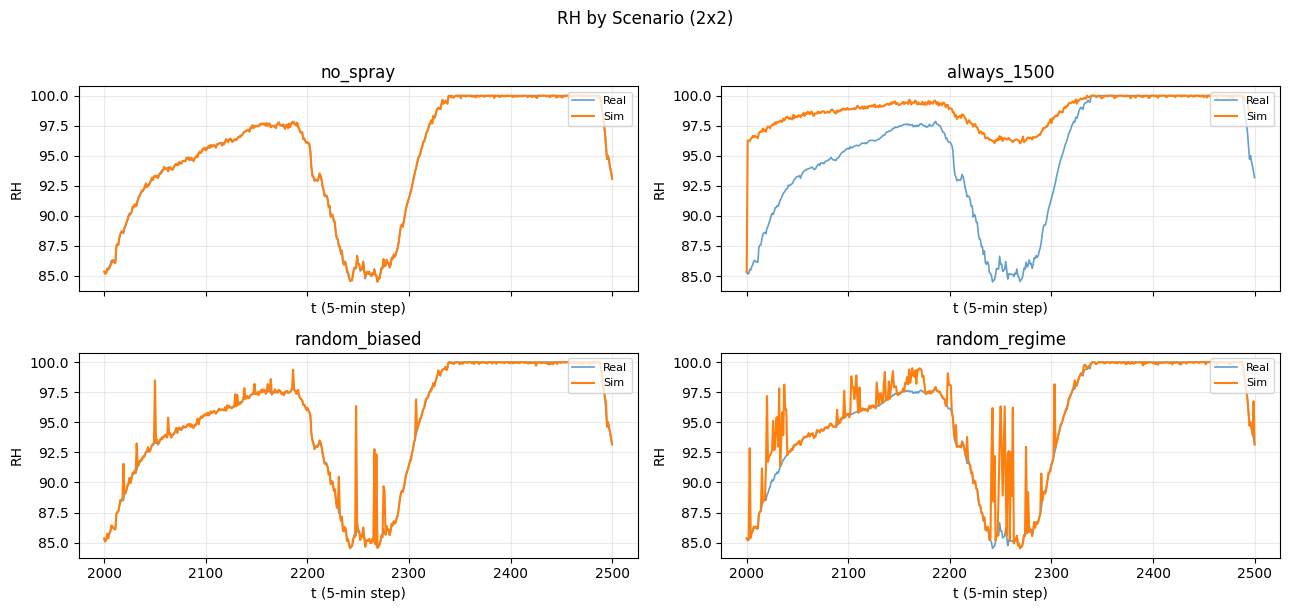

,case,steps,tvoc_start,tvoc_end,tvoc_change,tvoc_mae_vs_real,rh_start,rh_end,rh_change,tvoc_min,tvoc_max
0,no_spray,500,65.0,230.162946,165.162946,2.189975,85.34,93.054398,7.714398,28.126940,234.470583
1,always_1500,500,65.0,80.770223,15.770223,42.917901,85.34,98.227261,12.887261,2.794975,90.498407
2,random_biased,500,65.0,226.433280,161.433280,6.016851,85.34,93.162680,7.822680,7.397032,227.639465
3,random_regime,500,65.0,157.982661,92.982661,13.144941,85.34,93.150765,7.810765,2.160792,232.732713


In [34]:
if "plt" not in globals():
    import matplotlib.pyplot as plt

# Shared simulator/scenario defaults for reproducible quick checks.
SIM_INPUT_FILE = "pi-1-data-clean-5min.csv"
CASE_SUITE: list[str] = ["no_spray", "always_1500", "random_biased", "random_regime"]
CASE_RUN_STEPS = 500
CASE_RUN_T0 = 2000
CASE_RNG_SEED = 17

# Build simulator from pi-1 only.
base_dir = Path.cwd()
if "cleaned_frames" in globals() and "pi-1-data.csv" in cleaned_frames:
    pi1_df = cleaned_frames["pi-1-data.csv"].copy()
else:
    pi1_df = pd.read_csv(base_dir / SIM_INPUT_FILE)

sim = Pi1SpraySimulator(pi1_df)
print(f"Simulator initialized: T={sim.T} steps, action_space={sim.action_space()}")


def _safe_horizon(simulator: Pi1SpraySimulator, requested_steps: int) -> int:
    """Clamp rollout length to available replay horizon."""
    return max(2, min(int(requested_steps), simulator.T - 2))


def make_action_plan(
    case: str,
    steps: int,
    rng: np.random.Generator | None = None,
) -> list[int]:
    """Build categorical action sequence for scenario testing."""
    case_key = case.strip().lower()
    local_rng = rng if rng is not None else np.random.default_rng(CASE_RNG_SEED)

    if case_key in {"no_spray", "none", "case1"}:
        return [0] * steps

    if case_key in {"always_1500", "max", "case2"}:
        return [1500] * steps

    if case_key in {"random_biased", "random", "rare_spray", "case3"}:
        # No spray is dominant; higher concentrations are progressively rarer.
        actions = np.array(ACTION_CONCENTRATIONS, dtype=int)
        probs = np.array([0.90, 0.06, 0.03, 0.01], dtype=float)
        sampled = local_rng.choice(actions, size=steps, replace=True, p=probs)
        return sampled.tolist()

    if case_key in {"random_regime", "regime_switch", "bursty", "case4"}:
        # Regime-switching policy: long sparse periods and occasional bursty periods.
        actions = np.array(ACTION_CONCENTRATIONS, dtype=int)
        low_probs = np.array([0.96, 0.03, 0.009, 0.001], dtype=float)
        high_probs = np.array([0.20, 0.30, 0.30, 0.20], dtype=float)

        # Persistence creates contiguous periods in each regime.
        p_stay_low = 0.97
        p_stay_high = 0.93
        in_high_regime = bool(local_rng.random() < 0.15)

        sampled_actions: list[int] = []
        for _ in range(steps):
            if in_high_regime:
                sampled_actions.append(int(local_rng.choice(actions, p=high_probs)))
                if local_rng.random() > p_stay_high:
                    in_high_regime = False
            else:
                sampled_actions.append(int(local_rng.choice(actions, p=low_probs)))
                if local_rng.random() > p_stay_low:
                    in_high_regime = True

        return sampled_actions

    raise ValueError(
        "Unknown case. Use one of: no_spray, always_1500, random_biased, random_regime."
    )


def run_case(
    simulator: Pi1SpraySimulator,
    case: str,
    steps: int = 300,
    t0: int = 0,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Run one test case and return (simulated, real_reference) DataFrames."""
    safe_steps = _safe_horizon(simulator, steps)
    t0 = int(np.clip(t0, 0, simulator.T - safe_steps - 1))

    actions = make_action_plan(case, safe_steps, rng=simulator.rng)
    sim_df = simulator.rollout(actions, t0=t0).copy()

    real_slice = pd.DataFrame(
        {
            "t": np.arange(t0, t0 + safe_steps + 1),
            "tvoc_real": simulator.real_tvoc[t0 : t0 + safe_steps + 1],
            "co2_real": simulator.real_co2[t0 : t0 + safe_steps + 1],
            "temp_real": simulator.real_temp[t0 : t0 + safe_steps + 1],
            "rh_real": simulator.real_rh[t0 : t0 + safe_steps + 1],
        }
    )

    return sim_df, real_slice


def summarize_case(
    sim_df: pd.DataFrame, real_df: pd.DataFrame, case: str
) -> pd.DataFrame:
    """Compact metrics to support quick tuning iterations."""
    tvoc_start = float(sim_df["tvoc"].iloc[0])
    tvoc_end = float(sim_df["tvoc"].iloc[-1])
    rh_start = float(sim_df["rh"].iloc[0])
    rh_end = float(sim_df["rh"].iloc[-1])

    merged = sim_df.merge(real_df[["t", "tvoc_real"]], on="t", how="left")
    tvoc_mae = float((merged["tvoc"] - merged["tvoc_real"]).abs().mean())

    return pd.DataFrame(
        [
            {
                "case": case,
                "steps": int(len(sim_df) - 1),
                "tvoc_start": tvoc_start,
                "tvoc_end": tvoc_end,
                "tvoc_change": tvoc_end - tvoc_start,
                "tvoc_mae_vs_real": tvoc_mae,
                "rh_start": rh_start,
                "rh_end": rh_end,
                "rh_change": rh_end - rh_start,
                "tvoc_min": float(sim_df["tvoc"].min()),
                "tvoc_max": float(sim_df["tvoc"].max()),
            }
        ]
    )


def _scenario_grid(n_cases: int) -> tuple[int, int]:
    cols = 2
    rows = int(np.ceil(n_cases / cols))
    return rows, cols


def plot_metric_case_grid(
    case_runs: dict[str, tuple[pd.DataFrame, pd.DataFrame]],
    sim_col: str,
    real_col: str,
    y_label: str,
    title: str,
) -> None:
    """Plot one metric across all cases in a compact 2-column grid."""
    cases = list(case_runs.keys())
    rows, cols = _scenario_grid(len(cases))
    fig, axes = plt.subplots(rows, cols, figsize=(13, 3.0 * rows), sharex=True)
    axes_flat = np.atleast_1d(axes).ravel()

    for i, case in enumerate(cases):
        ax = axes_flat[i]
        sim_df, real_df = case_runs[case]
        ax.plot(real_df["t"], real_df[real_col], label="Real", alpha=0.7, linewidth=1.2)
        ax.plot(sim_df["t"], sim_df[sim_col], label="Sim", linewidth=1.5)
        ax.set_title(case)
        ax.set_ylabel(y_label)
        ax.grid(alpha=0.25)
        ax.legend(loc="upper right", fontsize=8)

    for j in range(len(cases), len(axes_flat)):
        axes_flat[j].set_visible(False)

    for ax in axes_flat[: len(cases)]:
        ax.set_xlabel("t (5-min step)")

    fig.suptitle(title, fontsize=12, y=1.01)
    fig.tight_layout()
    plt.show()


def plot_action_case_grid(
    case_runs: dict[str, tuple[pd.DataFrame, pd.DataFrame]],
) -> None:
    """Plot action schedules across all cases in a compact 2-column grid."""
    cases = list(case_runs.keys())
    rows, cols = _scenario_grid(len(cases))
    fig, axes = plt.subplots(rows, cols, figsize=(13, 3.0 * rows), sharex=True)
    axes_flat = np.atleast_1d(axes).ravel()

    for i, case in enumerate(cases):
        ax = axes_flat[i]
        sim_df, _ = case_runs[case]
        ax.step(sim_df["t"], sim_df["action"], where="post", linewidth=1.3)
        ax.set_title(case)
        ax.set_ylabel("Action")
        ax.grid(alpha=0.25)

    for j in range(len(cases), len(axes_flat)):
        axes_flat[j].set_visible(False)

    for ax in axes_flat[: len(cases)]:
        ax.set_xlabel("t (5-min step)")

    fig.suptitle("Action Schedules by Scenario", fontsize=12, y=1.01)
    fig.tight_layout()
    plt.show()


def run_three_case_suite(
    simulator: Pi1SpraySimulator,
    steps: int = 288,
    t0: int = 0,
    plot: bool = True,
) -> tuple[dict[str, pd.DataFrame], pd.DataFrame]:
    """Run case scenarios and return trajectories + summary metrics."""
    trajectories: dict[str, pd.DataFrame] = {}
    summary_frames: list[pd.DataFrame] = []
    case_runs: dict[str, tuple[pd.DataFrame, pd.DataFrame]] = {}

    for case in CASE_SUITE:
        sim_df, real_df = run_case(simulator, case=case, steps=steps, t0=t0)
        trajectories[case] = sim_df
        case_runs[case] = (sim_df, real_df)
        summary_frames.append(summarize_case(sim_df, real_df, case))

    if plot:
        plot_action_case_grid(case_runs)

        plot_metric_case_grid(
            case_runs,
            sim_col="tvoc",
            real_col="tvoc_real",
            y_label="TVOC",
            title="TVOC by Scenario (2x2)",
        )
        plot_metric_case_grid(
            case_runs,
            sim_col="co2",
            real_col="co2_real",
            y_label="CO2",
            title="CO2 by Scenario (2x2)",
        )
        plot_metric_case_grid(
            case_runs,
            sim_col="temp",
            real_col="temp_real",
            y_label="Temperature",
            title="Temperature by Scenario (2x2)",
        )
        plot_metric_case_grid(
            case_runs,
            sim_col="rh",
            real_col="rh_real",
            y_label="RH",
            title="RH by Scenario (2x2)",
        )

    summary_df = pd.concat(summary_frames, ignore_index=True)
    return trajectories, summary_df


# Execute default long-horizon checks.
case_trajectories, case_summary_df = run_three_case_suite(
    sim, steps=CASE_RUN_STEPS, t0=CASE_RUN_T0, plot=True
)
case_summary_df

### For tuning reward function normalization constants so term contributions have balanced scales and net the intended significance (scale) in the final reward


In [35]:
def compute_reward_terms(
    simulator: Pi1SpraySimulator,
    state_prev: np.ndarray,
    state_next: np.ndarray,
    action: int,
    t: int,
    reward_weights: RewardWeights | None = None,
) -> dict[str, float]:
    """Compute individual reward terms (not summed) for analysis. No scales applied."""
    w = reward_weights or simulator.cfg.reward
    tvoc_prev, co2_prev, _, _ = state_prev
    tvoc_next, co2_next, temp_next, rh_next = state_next

    safe_tvoc_threshold = w.tvoc_target
    safe_co2_threshold = w.co2_target

    # 1) TVOC (no scale)
    tvoc_delta = tvoc_prev - tvoc_next
    tvoc_progress_term = 0.0
    if w.use_tvoc_delta:
        tvoc_progress_term = np.clip(tvoc_delta / TVOC_PROGRESS_NORM, -2.0, 2.0)
    tvoc_excess = max(0.0, tvoc_next - safe_tvoc_threshold) / TVOC_EXCESS_NORM
    tvoc_excess_term = -tvoc_excess

    # 2) CO2 (no scale)
    co2_delta = co2_prev - co2_next
    co2_progress_term = 0.0
    if w.use_co2_delta:
        co2_progress_term = np.clip(co2_delta / CO2_PROGRESS_NORM, -2.0, 2.0)
    co2_excess = max(0.0, co2_next - safe_co2_threshold) / CO2_EXCESS_NORM
    co2_excess_term = -co2_excess

    # 3) THI (no scale)
    base_t = simulator.real_temp[t] if t < simulator.T - 1 else temp_next
    base_rh = simulator.real_rh[t] if t < simulator.T - 1 else rh_next
    baseline_thi = (0.8 * base_t) + ((base_rh / 100.0) * (base_t - 14.4)) + 46.4
    current_thi = (0.8 * temp_next) + ((rh_next / 100.0) * (temp_next - 14.4)) + 46.4
    safe_thi_threshold = max(73.0, baseline_thi)
    thi_excess = max(0.0, current_thi - safe_thi_threshold) / THI_EXCESS_NORM
    thi_term = -thi_excess

    # 4) RH (no scale)
    rh_excess = max(0.0, rh_next - w.rh_target) / RH_EXCESS_NORM
    rh_term = -rh_excess

    # 5) Cold (no scale)
    safe_temp_min = 18.0
    cold_excess = max(0.0, safe_temp_min - temp_next) / COLD_EXCESS_NORM
    cold_term = -cold_excess

    # 6) Action penalty (no scale, just normalized)
    dose_norm = float(action) / 1500.0
    action_term = -(dose_norm**w.action_curve_power)

    return {
        "tvoc_progress": tvoc_progress_term,
        "tvoc_excess": tvoc_excess_term,
        "co2_progress": co2_progress_term,
        "co2_excess": co2_excess_term,
        "thi": thi_term,
        "rh": rh_term,
        "cold": cold_term,
        "action": action_term,
    }


# Analyze reward term balance across scenarios
scenario_term_stats = {}

for case, traj_df in case_trajectories.items():
    term_accum = {
        "tvoc_progress": [],
        "tvoc_excess": [],
        "co2_progress": [],
        "co2_excess": [],
        "thi": [],
        "rh": [],
        "cold": [],
        "action": [],
    }

    # Reconstruct states and actions from trajectory
    for idx in range(len(traj_df) - 1):
        t_step = int(traj_df.loc[idx, "t"])
        if t_step >= sim.T - 2:
            break

        state_prev = np.array(
            [
                traj_df.loc[idx, "tvoc"],
                traj_df.loc[idx, "co2"],
                traj_df.loc[idx, "temp"],
                traj_df.loc[idx, "rh"],
            ],
            dtype=float,
        )
        state_next = np.array(
            [
                traj_df.loc[idx + 1, "tvoc"],
                traj_df.loc[idx + 1, "co2"],
                traj_df.loc[idx + 1, "temp"],
                traj_df.loc[idx + 1, "rh"],
            ],
            dtype=float,
        )
        action = int(traj_df.loc[idx + 1, "action"])

        terms = compute_reward_terms(
            sim, state_prev, state_next, action, t_step, sim.cfg.reward
        )
        for term_name, term_val in terms.items():
            term_accum[term_name].append(abs(term_val))

    # Compute stats
    term_stats = {}
    for term_name, vals in term_accum.items():
        if vals:
            term_stats[term_name] = float(np.mean(vals))
        else:
            term_stats[term_name] = 0.0

    scenario_term_stats[case] = term_stats

# Print summary
print("=" * 80)
print("REWARD TERM BALANCE ANALYSIS")
print("=" * 80)

for case, stats in scenario_term_stats.items():
    print(f"\n{case.upper()}:")
    print("  Term                    Mean |Contribution|")
    print("  " + "-" * 45)

    # Sort by magnitude descending
    sorted_terms = sorted(stats.items(), key=lambda x: abs(x[1]), reverse=True)
    max_val = max(abs(v) for v in stats.values()) if stats.values() else 1.0

    for term_name, term_val in sorted_terms:
        ratio_to_max = abs(term_val) / max_val if max_val > 0 else 1.0
        bar_len = int(ratio_to_max * 30)
        bar = "█" * bar_len
        print(f"  {term_name:18s}  {term_val:8.4f}  {bar}")

print("\n" + "=" * 80)


REWARD TERM BALANCE ANALYSIS

NO_SPRAY:
  Term                    Mean |Contribution|
  ---------------------------------------------
  tvoc_excess           1.3289  ██████████████████████████████
  co2_excess            1.1735  ██████████████████████████
  thi                   1.0463  ███████████████████████
  rh                    0.9910  ██████████████████████
  co2_progress          0.9050  ████████████████████
  tvoc_progress         0.7110  ████████████████
  cold                  0.0000  
  action                0.0000  

ALWAYS_1500:
  Term                    Mean |Contribution|
  ---------------------------------------------
  rh                    1.5231  ██████████████████████████████
  action                1.0000  ███████████████████
  tvoc_progress         0.9172  ██████████████████
  co2_progress          0.9099  █████████████████
  thi                   0.5350  ██████████
  co2_excess            0.5181  ██████████
  tvoc_excess           0.0871  █
  cold               

## 5. RL


### Shared RL setup


In [36]:
from __future__ import annotations

import copy
from dataclasses import dataclass
from typing import Literal

import numpy as np
import pandas as pd
import optuna

from dataclasses import dataclass, field

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO, DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv, VecNormalize


AlgoName = Literal["ppo", "dqn"]


@dataclass(frozen=True)
class RLRunConfig:
    max_steps: int = 250

    # Hyperparameter search
    tune_trials: int = 20
    tune_budget: int = 50_000
    eval_episodes: int = 20

    # Train/eval scaling
    budgets: tuple[int, ...] = (50_000, 100_000, 200_000)
    n_envs: int = 4
    seed: int = 42

    n_train_seeds: int = 3
    n_eval_seeds: int = 5
    eval_seed_stride: int = 10_000

    # Speed
    use_subproc: bool = False  # set True in a script, usually False in notebooks


RUN_CFG = RLRunConfig()

ALGO_CLASSES = {
    "ppo": PPO,
    "dqn": DQN,
}


@dataclass(frozen=True)
class EnvConfig:
    reward: RewardWeights = field(default_factory=RewardWeights)
    max_steps: int = 250
    gamma: float = 0.99
    tvoc_norm_divisor: float = TVOC_OBS_DIVISOR
    co2_norm_divisor: float = CO2_OBS_DIVISOR
    temp_norm_divisor: float = TEMP_OBS_DIVISOR
    rh_min: float = RH_OBS_MIN
    rh_span: float = RH_OBS_SPAN


# Post-normalization std should be in a similar ballpark across dims.
print("Post-normalization std per observation dimension:")
for name, series, divisor, shift in [
    ("tvoc", _obs_tvoc, TVOC_OBS_DIVISOR, 0.0),
    ("co2", _obs_co2, CO2_OBS_DIVISOR, 0.0),
    ("temp", _obs_temp, TEMP_OBS_DIVISOR, 0.0),
    ("rh", _obs_rh, RH_OBS_SPAN, RH_OBS_MIN),
]:
    normed = (series - shift) / divisor
    print(
        f"  {name:>6s}  std={normed.std():.3f}  min={normed.min():.3f}  max={normed.max():.3f}"
    )


class Pi1SprayEnv(gym.Env):
    """Gymnasium-compliant environment for deodorization spray control."""

    metadata = {"render_modes": []}

    def __init__(
        self,
        simulator: Pi1SpraySimulator,
        config: EnvConfig | None = None,
    ) -> None:
        self.sim = simulator
        self.cfg = config

        # Action space: categorical [0, 500, 1000, 1500]
        self.action_to_concentration = {
            idx: concentration
            for idx, concentration in enumerate(ACTION_CONCENTRATIONS)
        }
        self.action_space = spaces.Discrete(len(self.action_to_concentration))

        # Observation: [tvoc_norm, co2_norm, temp_norm, rh_norm, d_tvoc_norm, d_rh_norm]
        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0, 0.0, 0.0, -1.0, -1.0], dtype=np.float32),
            high=np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0], dtype=np.float32),
            dtype=np.float32,
        )

        self.state: np.ndarray = np.zeros(4, dtype=np.float32)
        self.t: int = 0
        self.steps_taken: int = 0

    def reset(
        self, seed: int | None = None, options: dict | None = None
    ) -> tuple[np.ndarray, dict]:
        super().reset(seed=seed)
        _ = options
        start_t = self.np_random.integers(0, max(1, self.sim.T - self.cfg.max_steps))
        self.t = start_t
        self.state = self.sim.reset(t0=start_t).astype(np.float32)
        self.steps_taken = 0

        obs = self._build_obs(self.state, d_tvoc_norm=0.0, d_rh_norm=0.0)
        return obs, {}

    def step(self, action: int) -> tuple[np.ndarray, float, bool, bool, dict]:
        dose = self.action_to_concentration[int(action)]
        state_prev = self.state.copy()
        next_state = self.sim.step(state_prev, dose, self.t).astype(np.float32)

        d_tvoc_norm = float(np.clip((next_state[0] - state_prev[0]) / 500.0, -1.0, 1.0))
        d_rh_norm = float(np.clip((next_state[3] - state_prev[3]) / 60.0, -1.0, 1.0))

        self.state = next_state
        self.t += 1
        self.steps_taken += 1

        terminated = self.t >= self.sim.T - 2
        truncated = self.steps_taken >= self.cfg.max_steps
        is_terminal = terminated or truncated

        reward = self.sim.compute_reward(
            tvoc_prev=float(state_prev[0]),
            tvoc_next=float(next_state[0]),
            co2_prev=float(state_prev[1]),
            co2_next=float(next_state[1]),
            temp_prev=float(state_prev[2]),
            temp_next=float(next_state[2]),
            rh_prev=float(state_prev[3]),
            rh_next=float(next_state[3]),
            action=dose,
            reward_weights=self.cfg.reward,
            is_terminal=is_terminal,
        )

        info = {
            "tvoc": float(self.state[0]),
            "co2": float(self.state[1]),
            "temp": float(self.state[2]),
            "rh": float(self.state[3]),
            "dose": dose,
            "d_tvoc_norm": d_tvoc_norm,
            "d_rh_norm": d_rh_norm,
        }

        obs = self._build_obs(self.state, d_tvoc_norm=d_tvoc_norm, d_rh_norm=d_rh_norm)
        return obs, reward, terminated, truncated, info

    def _build_obs(
        self, s: np.ndarray, d_tvoc_norm: float, d_rh_norm: float
    ) -> np.ndarray:
        base = np.array(
            [
                s[0] / self.cfg.tvoc_norm_divisor,
                s[1] / self.cfg.co2_norm_divisor,
                s[2] / self.cfg.temp_norm_divisor,
                (s[3] - self.cfg.rh_min) / self.cfg.rh_span,
            ],
            dtype=np.float32,
        )
        delta = np.array([d_tvoc_norm, d_rh_norm], dtype=np.float32)
        return np.concatenate([base, delta], axis=0)


Post-normalization std per observation dimension:
    tvoc  std=0.219  min=0.000  max=1.682
     co2  std=0.108  min=0.000  max=1.466
    temp  std=0.080  min=0.622  max=1.090
      rh  std=0.208  min=-0.382  max=1.000


### Environment builders, hyperparameter search, and model construction.


In [37]:
def make_env_cfg(sim, gamma: float) -> EnvConfig:
    return EnvConfig(
        reward=sim.cfg.reward,
        max_steps=RUN_CFG.max_steps,
        gamma=gamma,
    )


def make_env_fn(base_sim, env_cfg: EnvConfig, seed: int, rank: int):
    def _init():
        sim_i = copy.deepcopy(base_sim)
        sim_i.rng = np.random.default_rng(seed + 10_000 * rank)
        env = Pi1SprayEnv(sim_i, config=env_cfg)
        return Monitor(env)

    return _init


def build_vec_env(
    base_sim,
    env_cfg: EnvConfig,
    seed: int,
    n_envs: int,
    normalize: bool = True,
    use_subproc: bool = False,
    gamma: float = 0.99,
):
    vec_cls = SubprocVecEnv if use_subproc else DummyVecEnv
    env_fns = [make_env_fn(base_sim, env_cfg, seed, rank) for rank in range(n_envs)]
    vec_env = vec_cls(env_fns)

    if normalize:
        vec_env = VecNormalize(
            vec_env,
            norm_obs=True,
            norm_reward=True,
            clip_obs=10.0,
            clip_reward=10.0,
            gamma=gamma,
        )
    return vec_env


def sync_vecnormalize(train_env, eval_env):
    # Copy running statistics from training env to eval env.
    eval_env.obs_rms = copy.deepcopy(train_env.obs_rms)
    eval_env.ret_rms = copy.deepcopy(train_env.ret_rms)
    eval_env.training = False
    eval_env.norm_reward = False
    return eval_env


def make_eval_env(base_sim, env_cfg: EnvConfig, train_env, seed: int):
    eval_env = build_vec_env(
        base_sim=base_sim,
        env_cfg=env_cfg,
        seed=seed,
        n_envs=1,
        normalize=True,
        use_subproc=False,
        gamma=env_cfg.gamma,
    )
    return sync_vecnormalize(train_env, eval_env)


def sample_hyperparams(algo: AlgoName, trial: optuna.Trial) -> dict:
    if algo == "ppo":
        # Optune complains about tuples not suitable for persistent storage
        net_arch_str = trial.suggest_categorical(
            "net_arch", ["64,64", "128,128", "256,256"]
        )
        net_arch = tuple(int(x) for x in net_arch_str.split(","))
        return {
            "learning_rate": trial.suggest_float("learning_rate", 1e-5, 3e-4, log=True),
            "n_steps": trial.suggest_categorical("n_steps", [64, 128, 256]),
            "batch_size": trial.suggest_categorical("batch_size", [64, 128]),
            "n_epochs": trial.suggest_categorical("n_epochs", [5, 10]),
            "gamma": trial.suggest_float("gamma", 0.95, 0.9999),
            "gae_lambda": trial.suggest_float("gae_lambda", 0.90, 0.98),
            "clip_range": trial.suggest_float("clip_range", 0.10, 0.30),
            "ent_coef": trial.suggest_float("ent_coef", 1e-4, 2e-2, log=True),
            "policy_kwargs": {"net_arch": list(net_arch)},
        }

    if algo == "dqn":
        net_arch_str = trial.suggest_categorical(
            "net_arch", ["64,64", "128,128", "256,256"]
        )
        net_arch = tuple(int(x) for x in net_arch_str.split(","))
        return {
            "learning_rate": trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True),
            "buffer_size": trial.suggest_categorical(
                "buffer_size", [50_000, 100_000, 200_000]
            ),
            "learning_starts": trial.suggest_categorical(
                "learning_starts", [1_000, 5_000, 10_000]
            ),
            "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128]),
            "train_freq": trial.suggest_categorical("train_freq", [1, 4]),
            "gradient_steps": trial.suggest_categorical("gradient_steps", [1, 4]),
            "target_update_interval": trial.suggest_categorical(
                "target_update_interval", [250, 500, 1000]
            ),
            "exploration_fraction": trial.suggest_float(
                "exploration_fraction", 0.05, 0.30
            ),
            "exploration_final_eps": trial.suggest_float(
                "exploration_final_eps", 0.01, 0.10
            ),
            "gamma": trial.suggest_float("gamma", 0.95, 0.9999),
            "policy_kwargs": {"net_arch": list(net_arch)},
        }

    raise ValueError(f"Unknown algo: {algo}")


def finalize_params(params: dict) -> dict:
    params = dict(params)
    if "net_arch" in params:
        raw = params.pop("net_arch")
        if isinstance(raw, str):
            net_arch = tuple(int(x) for x in raw.split(","))
        else:
            net_arch = tuple(raw)
        params["policy_kwargs"] = {"net_arch": list(net_arch)}
    return params


def build_model(
    algo: AlgoName,
    train_env,
    params: dict,
    seed: int,
):
    cls = ALGO_CLASSES[algo]
    common = dict(
        policy="MlpPolicy",
        env=train_env,
        seed=seed,
        device="cpu",
        verbose=0,
    )
    return cls(**common, **params)


### Evaluation, tuning, and budget sweep.


In [38]:
def evaluate_model(
    model,
    eval_env,
    env_cfg: EnvConfig,
    n_episodes: int = 20,
    seed: int = 42,
) -> pd.DataFrame:
    reward_list: list[float] = []
    tvoc_delta_list: list[float] = []
    rh_excess_list: list[float] = []
    co2_list: list[float] = []
    temp_list: list[float] = []
    action_counts = {dose: 0 for dose in ACTION_CONCENTRATIONS}
    step_tvoc_hit = 0
    step_co2_hit = 0
    step_count = 0

    for ep in range(n_episodes):
        eval_env.seed(seed + ep)
        obs = eval_env.reset()

        # Raw initial state is stored inside the wrapped env.
        tvoc_start = float(eval_env.get_attr("state")[0][0])

        ep_reward = 0.0
        last_info = None
        done = [False]

        while not done[0]:
            action, _ = model.predict(obs, deterministic=True)
            obs, rewards, done, infos = eval_env.step(action)

            ep_reward += float(rewards[0])
            info = infos[0]
            last_info = info

            dose = int(info["dose"])
            action_counts[dose] += 1

            tvoc = float(info["tvoc"])
            co2 = float(info["co2"])
            temp = float(info["temp"])
            rh = float(info["rh"])

            tvoc_delta_list.append(tvoc - tvoc_start)
            rh_excess_list.append(max(0.0, rh - env_cfg.reward.rh_target))
            co2_list.append(co2)
            temp_list.append(temp)

            if tvoc <= env_cfg.reward.tvoc_target:
                step_tvoc_hit += 1
            if co2 <= env_cfg.reward.co2_target:
                step_co2_hit += 1
            step_count += 1

        reward_list.append(ep_reward)

        if last_info is None:
            continue

    total_actions = max(1, sum(action_counts.values()))
    action_ratio = {
        f"concentration_{dose}_ratio": action_counts[dose] / total_actions
        for dose in ACTION_CONCENTRATIONS
    }
    action_probs = np.array(
        [action_counts[d] / total_actions for d in ACTION_CONCENTRATIONS], dtype=float
    )
    action_entropy = float(
        -(action_probs[action_probs > 0] * np.log(action_probs[action_probs > 0])).sum()
    )
    dominant_action_ratio = float(action_probs.max())

    out = {
        "episodes": n_episodes,
        "reward_mean": float(np.mean(reward_list)),
        "reward_std": float(np.std(reward_list)),
        "tvoc_delta_mean": float(np.mean(tvoc_delta_list))
        if tvoc_delta_list
        else np.nan,
        "tvoc_delta_std": float(np.std(tvoc_delta_list)) if tvoc_delta_list else np.nan,
        "mean_rh_excess": float(np.mean(rh_excess_list)) if rh_excess_list else np.nan,
        "mean_co2": float(np.mean(co2_list)) if co2_list else np.nan,
        "mean_temp": float(np.mean(temp_list)) if temp_list else np.nan,
        "tvoc_target_hit_rate": step_tvoc_hit / max(1, step_count),
        "co2_target_hit_rate": step_co2_hit / max(1, step_count),
        "action_entropy": action_entropy,
        "dominant_action_ratio": dominant_action_ratio,
        **action_ratio,
    }
    return pd.DataFrame([out])


def tune_hyperparams(
    algo: AlgoName,
    base_sim,
    run_cfg: RLRunConfig = RUN_CFG,
) -> dict:
    def objective(trial: optuna.Trial) -> float:
        params = finalize_params(sample_hyperparams(algo, trial))
        gamma = float(params.get("gamma", 0.99))
        env_cfg = make_env_cfg(base_sim, gamma=gamma)

        train_env = build_vec_env(
            base_sim=base_sim,
            env_cfg=env_cfg,
            seed=run_cfg.seed + trial.number * 1000,
            n_envs=run_cfg.n_envs,
            normalize=True,
            use_subproc=run_cfg.use_subproc,
            gamma=gamma,
        )
        model = build_model(algo, train_env, params, seed=run_cfg.seed + trial.number)
        model.learn(total_timesteps=run_cfg.tune_budget)

        eval_env = make_eval_env(
            base_sim=base_sim,
            env_cfg=env_cfg,
            train_env=train_env,
            seed=run_cfg.seed + 50_000 + trial.number,
        )
        metrics = evaluate_model(
            model=model,
            eval_env=eval_env,
            env_cfg=env_cfg,
            n_episodes=max(5, run_cfg.eval_episodes // 2),
            seed=run_cfg.seed + 100_000 + trial.number,
        )

        train_env.close()
        eval_env.close()
        return float(metrics.loc[0, "reward_mean"])

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=run_cfg.tune_trials, show_progress_bar=True)
    return finalize_params(study.best_params)


def train_one_budget(
    algo: AlgoName,
    base_sim,
    env_cfg: EnvConfig,
    params: dict,
    total_timesteps: int,
    run_cfg: RLRunConfig = RUN_CFG,
):
    train_env = build_vec_env(
        base_sim=base_sim,
        env_cfg=env_cfg,
        seed=run_cfg.seed,
        n_envs=run_cfg.n_envs,
        normalize=True,
        use_subproc=run_cfg.use_subproc,
        gamma=params.get("gamma", 0.99),
    )
    model = build_model(algo, train_env, params, seed=run_cfg.seed)

    model.learn(total_timesteps=total_timesteps)

    eval_env = make_eval_env(
        base_sim=base_sim,
        env_cfg=env_cfg,
        train_env=train_env,
        seed=run_cfg.seed + 999,
    )
    metrics = evaluate_model(
        model=model,
        eval_env=eval_env,
        env_cfg=env_cfg,
        n_episodes=run_cfg.eval_episodes,
        seed=run_cfg.seed + 1_000,
    )
    metrics.insert(0, "algo", algo)
    metrics["timesteps"] = int(total_timesteps)

    train_env.close()
    eval_env.close()

    return model, metrics

### Run tuning once per algorithm, then sweep multiple budgets.


In [ ]:
algorithms_to_run = ("ppo", "dqn")
best_params_by_algo: dict[str, dict] = {}

for algo in algorithms_to_run:
    print(f"\nTuning {algo.upper()} ...")
    best_params = tune_hyperparams(algo, sim, RUN_CFG)
    best_params_by_algo[algo] = best_params
    print(f"Best {algo.upper()} params:\n{best_params}")

print("Summarize of best hyperparameters found:")
for algo, params in best_params_by_algo.items():
    print(f"{algo.upper()}: {params}")

[I 2026-05-03 13:34:00,172] A new study created in memory with name: no-name-56ca0452-fa03-413f-ae2f-25bd9e88eef2



Tuning PPO ...


Best trial: 0. Best value: -877.372:   5%|▌         | 1/20 [00:13<04:08, 13.07s/it]

[I 2026-05-03 13:34:13,246] Trial 0 finished with value: -877.3724401135463 and parameters: {'net_arch': '256,256', 'learning_rate': 0.00014774686185690345, 'n_steps': 64, 'batch_size': 128, 'n_epochs': 10, 'gamma': 0.9510695417785632, 'gae_lambda': 0.9534688575695184, 'clip_range': 0.17005019846217118, 'ent_coef': 0.00014444332679002927}. Best is trial 0 with value: -877.3724401135463.


Best trial: 0. Best value: -877.372:  10%|█         | 2/20 [00:23<03:31, 11.73s/it]

...

[I 2026-05-03 13:41:32,762] Trial 11 finished with value: -740.5279607988953 and parameters: {'net_arch': '256,256', 'learning_rate': 0.0008465779672160509, 'buffer_size': 100000, 'learning_starts': 1000, 'batch_size': 32, 'train_freq': 1, 'gradient_steps': 1, 'target_update_interval': 1000, 'exploration_fraction': 0.05809886723371791, 'exploration_final_eps': 0.09948229456383674, 'gamma': 0.9988217399496998}. Best is trial 8 with value: -472.0921303098788.


Best trial: 8. Best value: -472.092:  65%|██████▌   | 13/20 [03:48<02:05, 17.87s/it]

[I 2026-05-03 13:41:48,951] Trial 12 finished with value: -791.5483155486872 and parameters: {'net_arch': '256,256', 'learning_rate': 0.0009132309407713683, 'buffer_size': 100000, 'learning_starts': 1000, 'batch_size': 32, 'train_freq': 1, 'gradient_steps': 1, 'target_update_interval': 1000, 'exploration_fraction': 0.05257778249284098, 'exploration_final_eps': 0.07887177287539124, 'gamma': 0.9996804710893892}. Best is trial 8 with value: -472.0921303098788.


Best trial: 8. Best value: -472.092:  70%|███████   | 14/20 [04:04<01:42, 17.15s/it]

[I 2026-05-03 13:42:04,426] Trial 13 finished with value: -769.9963588210195 and parameters: {'net_arch': '256,256', 'learning_rate': 0.00024514911083123254, 'buffer_size': 100000, 'learning_starts': 1000, 'batch_size': 32, 'train_freq': 1, 'gradient_steps': 1, 'target_update_interval': 1000, 'exploration_fraction': 0.19150533236133643, 'exploration_final_eps': 0.08917008054356151, 'gamma': 0.9931697810039608}. Best is trial 8 with value: -472.0921303098788.


In [ ]:
all_rows: list[pd.DataFrame] = []

for algo in algorithms_to_run:
    best_params = best_params_by_algo[algo]
    gamma = float(best_params.get("gamma", 0.99))
    env_cfg = make_env_cfg(sim, gamma=gamma)

    for budget in RUN_CFG.budgets:
        print(f"\nTraining {algo.upper()} for {budget:,} timesteps ...")
        _, metrics = train_one_budget(
            algo=algo,
            base_sim=sim,
            env_cfg=env_cfg,
            params=best_params,
            total_timesteps=budget,
            run_cfg=RUN_CFG,
        )
        metrics.insert(0, "gamma", gamma)
        all_rows.append(metrics)
        print(metrics.to_string(index=False))

results_df = pd.concat(all_rows, ignore_index=True)
results_df = results_df.sort_values(["algo", "timesteps"]).reset_index(drop=True)
results_df


Training PPO for 50,000 timesteps ...
   gamma algo  episodes  reward_mean  reward_std  tvoc_delta_mean  tvoc_delta_std  mean_rh_excess   mean_co2  mean_temp  tvoc_target_hit_rate  co2_target_hit_rate  action_entropy  dominant_action_ratio  concentration_0_ratio  concentration_500_ratio  concentration_1000_ratio  concentration_1500_ratio  timesteps
0.985927  ppo        20  -780.701195  236.220842        -61.71993       66.419577        5.299046 497.858453  26.491251                 0.367               0.1006        1.121711                 0.4786                 0.4786                   0.0212                    0.2118                    0.2884      50000

Training PPO for 100,000 timesteps ...
   gamma algo  episodes  reward_mean  reward_std  tvoc_delta_mean  tvoc_delta_std  mean_rh_excess  mean_co2  mean_temp  tvoc_target_hit_rate  co2_target_hit_rate  action_entropy  dominant_action_ratio  concentration_0_ratio  concentration_500_ratio  concentration_1000_ratio  concentration_1500_

## 7. Demo Code for Online Update Loop with Real Data Feed

Only for showing what it would look like to adapt this approach to when real data will be available. By then, the agent and Gym environment will continuously collect transitions and periodically continue training.

Caution: this loop runs indefinitely (`while True`), and is not intended to be run per the above description.
